# 01 - Explore the BRACOL leaf dataset

Source: BRACOL (Krohling et al., Mendeley Data, CC BY 4.0) - Arabica coffee leaves photographed in Brazil.

Columns in `dataset.csv`:
- `predominant_stress` - the class label (0 healthy, 1 leaf miner, 2 rust, 3 brown leaf spot / phoma, 4 cercospora, 5 no predominant stress)
- `miner`, `rust`, `phoma`, `cercospora` - 0/1 flags for every stress visible on the leaf
- `severity` - how much of the leaf is damaged (0 healthy, 1 very low, 2 low, 3 high, 4 very high)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

ROOT = Path.cwd()
while not (ROOT / "data_raw").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data_raw" / "leaf"
IMAGES = DATA / "images"

STRESS_NAMES = {
    0: "healthy",
    1: "leaf miner",
    2: "rust",
    3: "phoma\n(brown leaf spot)",
    4: "cercospora",
    5: "no predominant\nstress",
}
SEVERITY_NAMES = {0: "healthy", 1: "very low", 2: "low", 3: "high", 4: "very high"}
FLAGS = ["miner", "rust", "phoma", "cercospora"]

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

In [2]:
df = pd.read_csv(DATA / "dataset.csv")
df["path"] = df["id"].map(lambda i: IMAGES / f"{i}.jpg")
df = df[df["path"].map(Path.exists)].reset_index(drop=True)
df["n_stresses"] = df[FLAGS].sum(axis=1)

print(f"leaves with an image: {len(df)}")
df.head()

leaves with an image: 1402


,id,predominant_stress,miner,rust,phoma,cercospora,severity,path,n_stresses
0,1,0,0,0,0,0,0,/Users/tamhowang/Desktop/hacknation-hackathon/...,0
1,2,0,0,0,0,0,0,/Users/tamhowang/Desktop/hacknation-hackathon/...,0
2,3,0,0,0,0,0,0,/Users/tamhowang/Desktop/hacknation-hackathon/...,0
3,4,0,0,0,0,0,0,/Users/tamhowang/Desktop/hacknation-hackathon/...,0
4,5,0,0,0,0,0,0,/Users/tamhowang/Desktop/hacknation-hackathon/...,0


## Label distributions

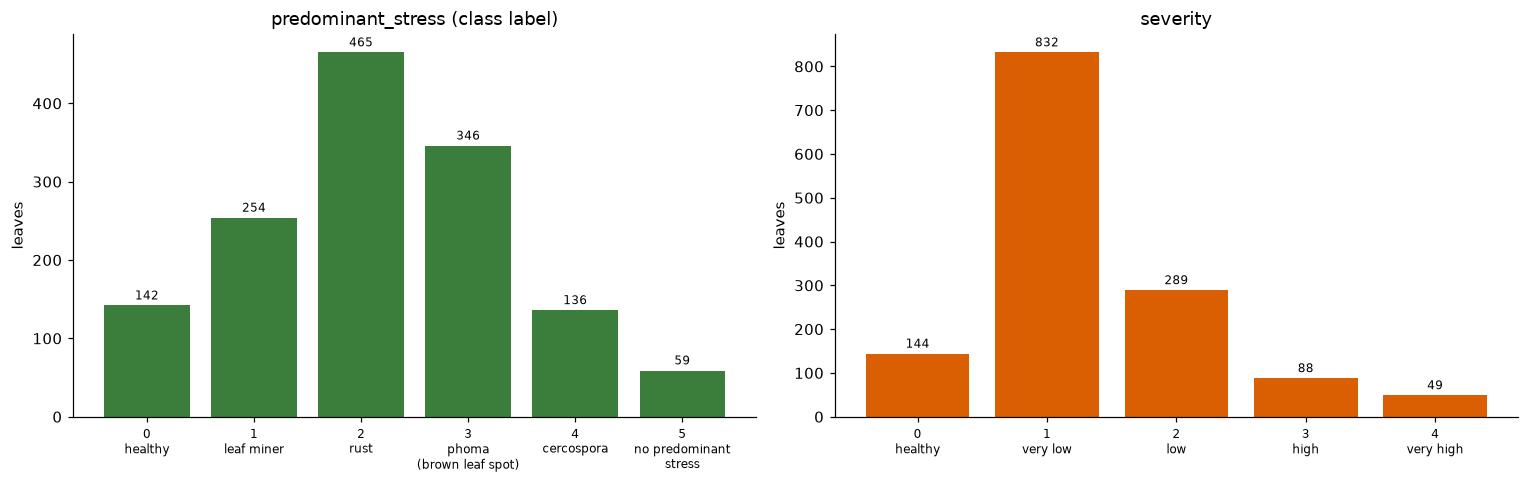

In [3]:
def bar_counts(col, names, title, ax, color="#3b7d3b"):
    keys = sorted(names)
    counts = df[col].value_counts().reindex(keys, fill_value=0)
    bars = ax.bar(range(len(keys)), counts, color=color)
    ax.bar_label(bars, padding=2, fontsize=8)
    ax.set_xticks(range(len(keys)), [f"{k}\n{names[k]}" for k in keys], fontsize=8)
    ax.set_ylabel("leaves")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
bar_counts("predominant_stress", STRESS_NAMES, "predominant_stress (class label)", axes[0])
bar_counts("severity", SEVERITY_NAMES, "severity", axes[1], color="#d95f02")
plt.tight_layout()

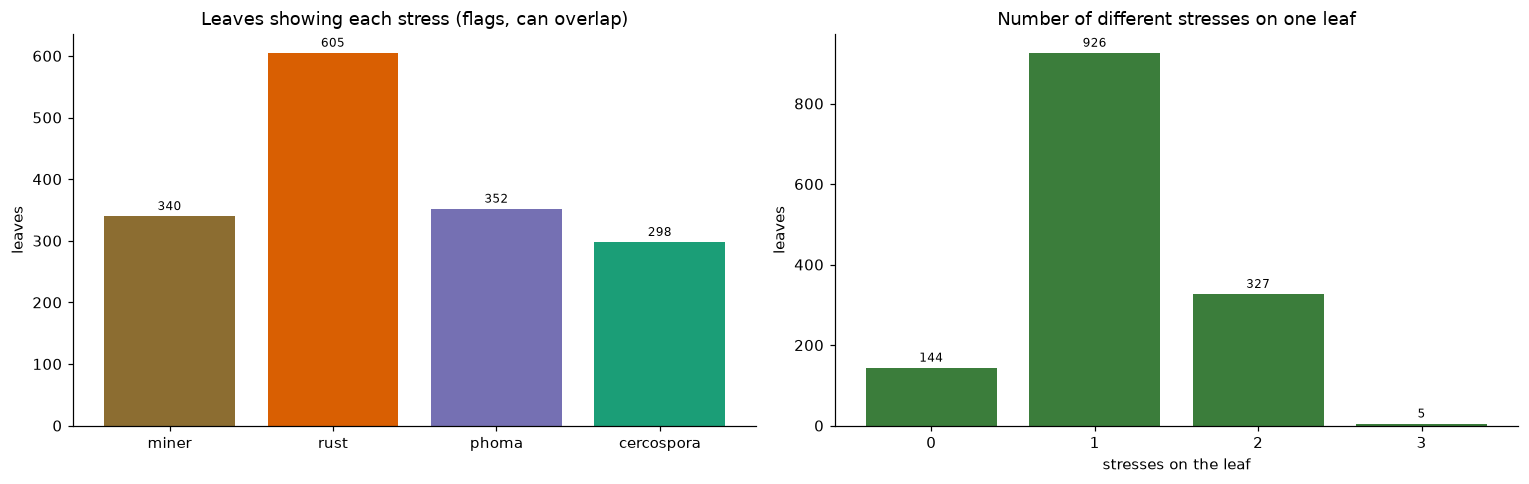

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

flag_counts = df[FLAGS].sum()
bars = axes[0].bar(FLAGS, flag_counts, color=["#8c6d31", "#d95f02", "#7570b3", "#1b9e77"])
axes[0].bar_label(bars, padding=2, fontsize=8)
axes[0].set_title("Leaves showing each stress (flags, can overlap)")
axes[0].set_ylabel("leaves")

n_counts = df["n_stresses"].value_counts().sort_index()
bars = axes[1].bar(n_counts.index.astype(str), n_counts, color="#3b7d3b")
axes[1].bar_label(bars, padding=2, fontsize=8)
axes[1].set_title("Number of different stresses on one leaf")
axes[1].set_xlabel("stresses on the leaf")
axes[1].set_ylabel("leaves")
plt.tight_layout()

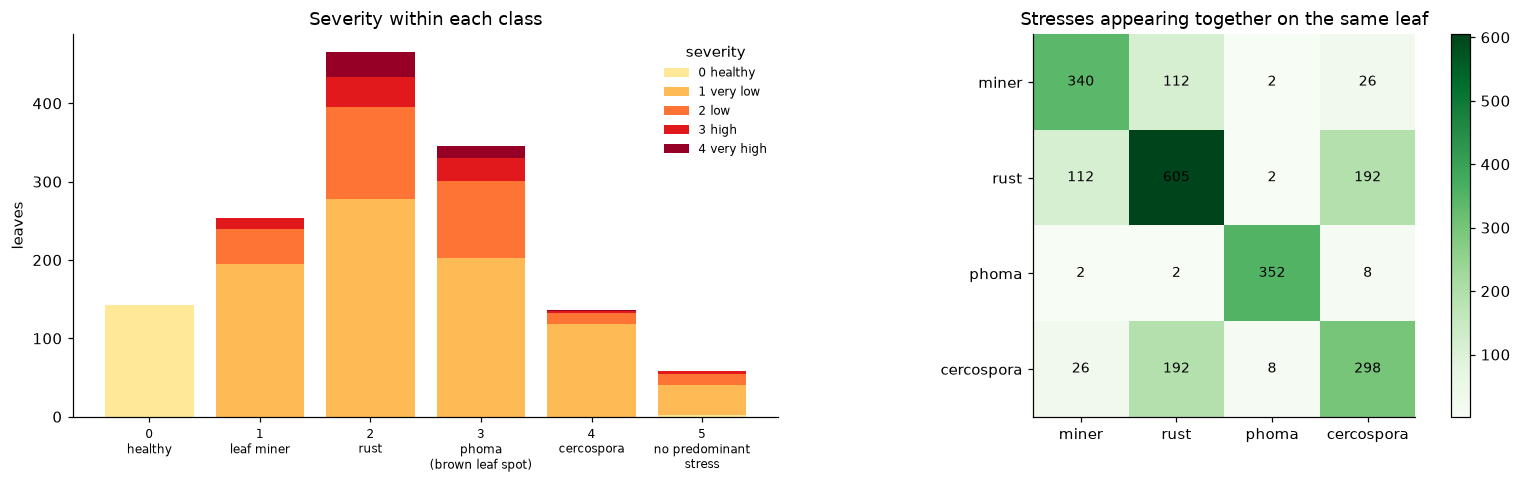

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sev = pd.crosstab(df["predominant_stress"], df["severity"]).reindex(columns=range(5), fill_value=0)
bottom = np.zeros(len(sev))
colors = plt.cm.YlOrRd(np.linspace(0.15, 0.95, 5))
for s in range(5):
    axes[0].bar(sev.index.astype(str), sev[s], bottom=bottom, color=colors[s], label=f"{s} {SEVERITY_NAMES[s]}")
    bottom += sev[s].values
axes[0].set_xticks(range(len(sev)), [f"{k}\n{STRESS_NAMES[k]}" for k in sev.index], fontsize=8)
axes[0].set_title("Severity within each class")
axes[0].set_ylabel("leaves")
axes[0].legend(title="severity", frameon=False, fontsize=8)

co = pd.DataFrame({c: df.loc[df[c] == 1, FLAGS].sum() for c in FLAGS})
im = axes[1].imshow(co.values, cmap="Greens")
axes[1].set_xticks(range(4), FLAGS)
axes[1].set_yticks(range(4), FLAGS)
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, co.values[i, j], ha="center", va="center", fontsize=9)
axes[1].set_title("Stresses appearing together on the same leaf")
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()

In [6]:
multi = df.groupby("predominant_stress")["n_stresses"].apply(lambda s: (s > 1).mean() * 100)
pd.DataFrame({
    "class": [STRESS_NAMES[k] for k in multi.index],
    "images": df["predominant_stress"].value_counts().sort_index().values,
    "% with more than one stress": multi.round(1).values,
}).set_index("class")

,images,% with more than one stress
class,,
healthy,142,0.0
leaf miner,254,19.3
rust,465,34.8
phoma\n(brown leaf spot),346,2.0
cercospora,136,44.1
no predominant\nstress,59,91.5


## One example per class

Where possible the example only carries its own stress flag, so the symptom shown is unambiguous.

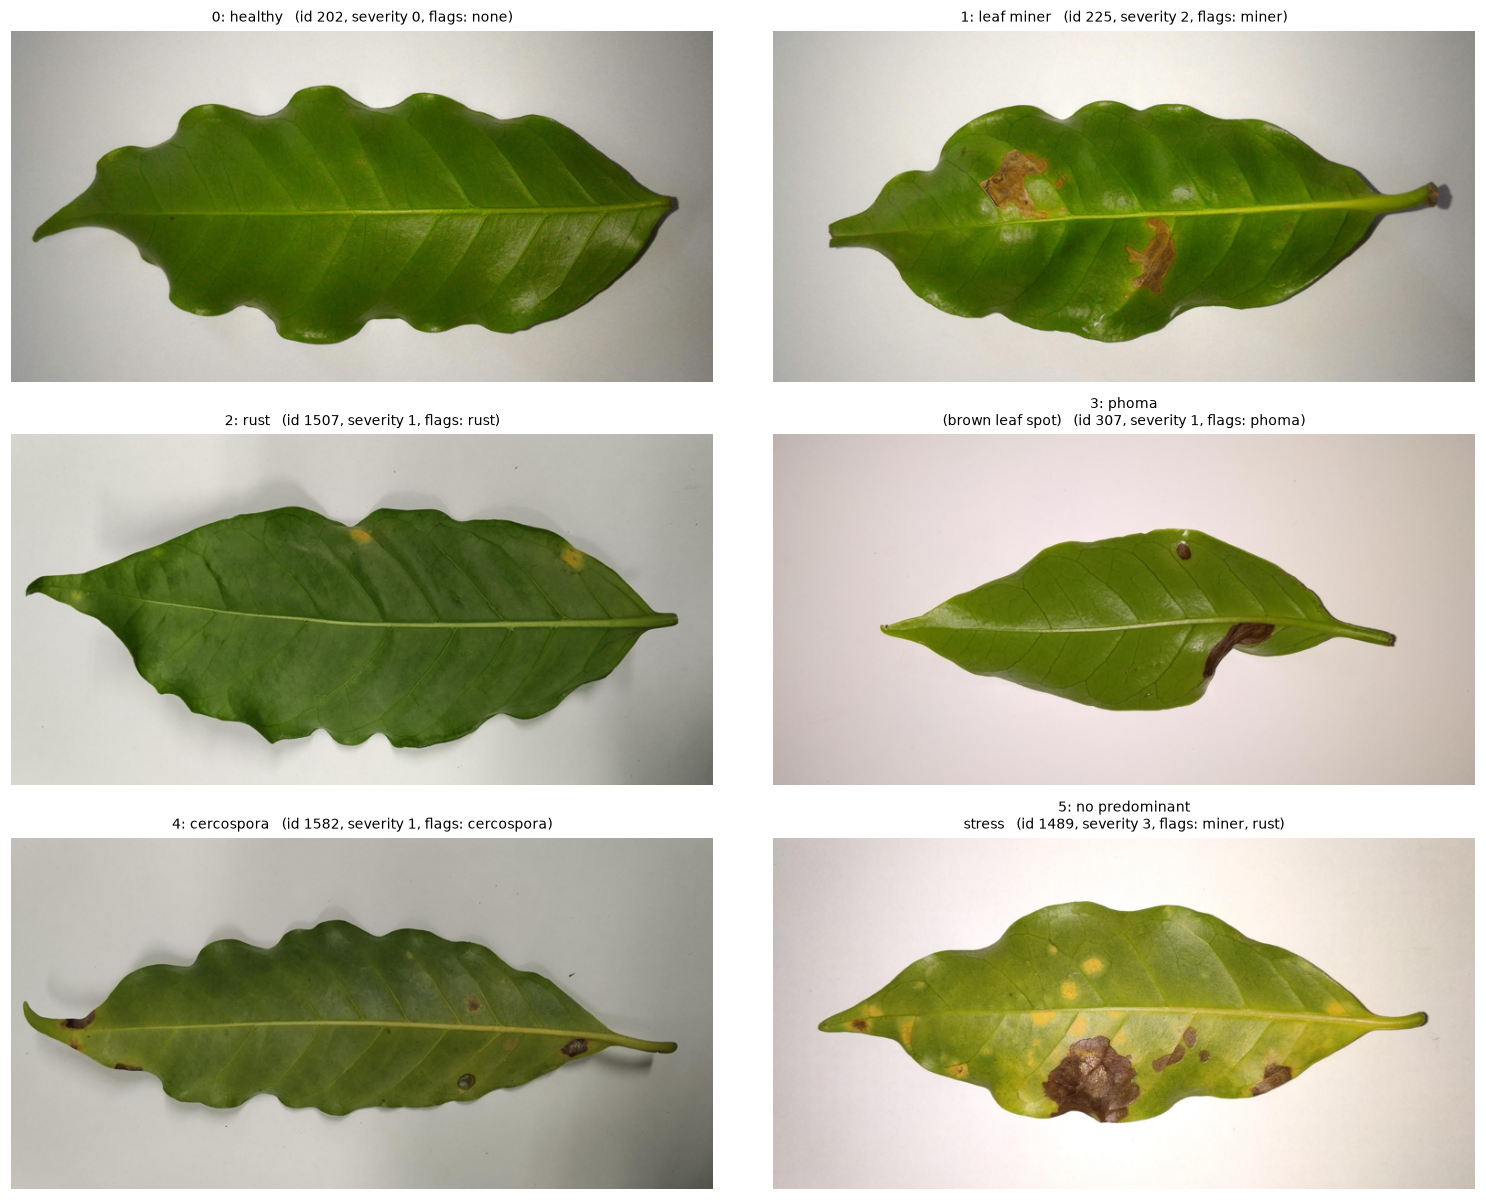

In [7]:
def load(path, width=768):
    img = Image.open(path).convert("RGB")
    return img.resize((width, int(img.height * width / img.width)))

def pick(rows, seed=0):
    return rows.sample(1, random_state=seed).iloc[0]

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for ax, k in zip(axes.flat, sorted(STRESS_NAMES)):
    rows = df[df["predominant_stress"] == k]
    if 1 <= k <= 4:
        clean = rows[rows["n_stresses"] == 1]
        rows = clean if len(clean) else rows
    r = pick(rows)
    present = [f for f in FLAGS if r[f]] or ["none"]
    ax.imshow(load(r["path"]))
    ax.set_title(f"{k}: {STRESS_NAMES[k]}   (id {r['id']}, severity {r['severity']}, flags: {', '.join(present)})", fontsize=9)
    ax.axis("off")
plt.tight_layout()

## One example per severity level

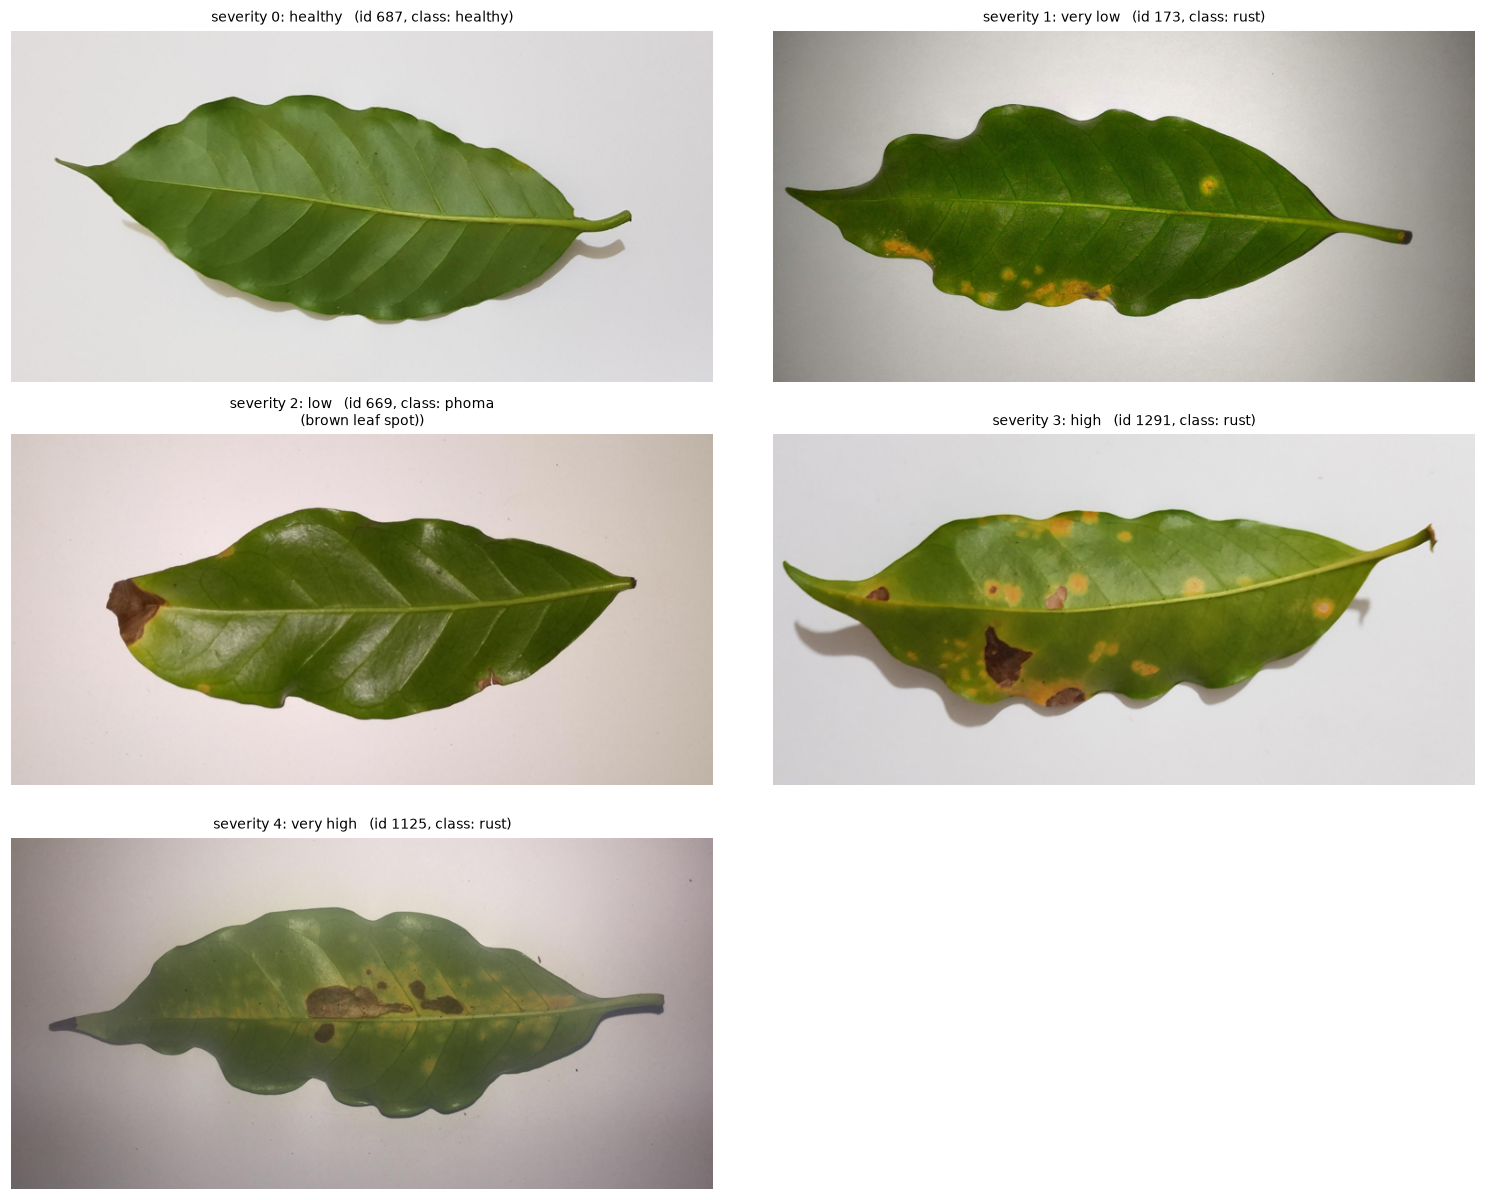

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for ax, s in zip(axes.flat, sorted(SEVERITY_NAMES)):
    r = pick(df[df["severity"] == s], seed=1)
    ax.imshow(load(r["path"]))
    ax.set_title(f"severity {s}: {SEVERITY_NAMES[s]}   (id {r['id']}, class: {STRESS_NAMES[r['predominant_stress']]})", fontsize=9)
    ax.axis("off")
axes.flat[-1].axis("off")
plt.tight_layout()

## Close-up: how big are the lesions?

The model will see the image at about 224 px wide. Small lesions shrink to a few pixels at that size.

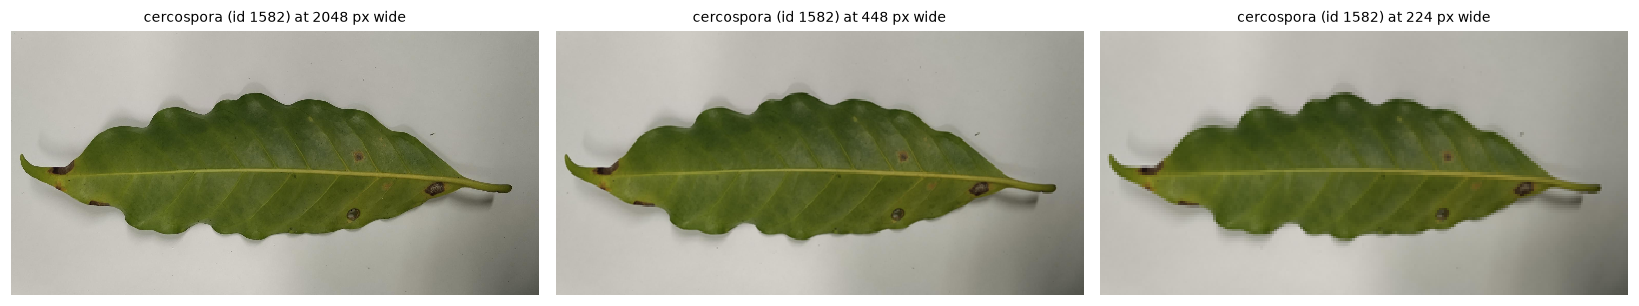

In [9]:
r = pick(df[(df["predominant_stress"] == 4) & (df["n_stresses"] == 1)])
full = Image.open(r["path"]).convert("RGB")
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, w in zip(axes, [full.width, 448, 224]):
    ax.imshow(full.resize((w, int(full.height * w / full.width))), interpolation="nearest")
    ax.set_title(f"cercospora (id {r['id']}) at {w} px wide", fontsize=9)
    ax.axis("off")
plt.tight_layout()

## Image sizes

In [10]:
sizes = df["path"].sample(200, random_state=0).map(lambda p: Image.open(p).size)
sizes.value_counts()

path
(2048, 1024)    200
Name: count, dtype: int64